In [1]:
import pandas as pd
import numpy as np
import sklearn.preprocessing
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from scipy.stats import zscore
import matplotlib.pyplot as plt
import seaborn as sns
import phate

import rmm
import cupy
import cudf
import cupy as cp
from rmm.allocators.cupy import rmm_cupy_allocator
import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

from cuml.manifold import UMAP
from cuml.decomposition import TruncatedSVD

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

# Load data

In [2]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/cell_cycle/TrajNet_input.h5ad"
adata = sc.read_h5ad(fpath)
adata

CPU times: user 298 ms, sys: 3.05 s, total: 3.34 s
Wall time: 7.29 s


AnnData object with n_obs × n_vars = 6895 × 15906
    obs: 'batch', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'n_reads', 'raw_clusters', 'bbknn_clusters', 'harmony_clusters', 'cluster_str', 'barcoded_phase', 'S_score', 'G2M_score', 'dpt_pseudotime', 'dpt_groups', 'dpt_order', 'dpt_order_indices', 'G1_pseudotime', 'G1_order', 'G2M_pseudotime', 'G2M_order', 'mean_pseudotime', 'mean_order', 'nnz', 'velocyto_cell_id', 'cell_id', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'leiden', 'cluster_phase', 'early_g1_score', 'G1_stage', 'global_ordering', 'global_ordering_bin', 'velocity_self_tra

In [3]:
print(adata.obs[['cluster_phase', 'sample_labels']].head().to_string())

                   cluster_phase  sample_labels
AAACCAAAGGGTAGCA-1             S              4
AAACCAAAGTAAGGGT-1            G1              0
AAACCATTCAGGTAGG-1           G2M              5
AAACCATTCCAGCCCT-1            G1              2
AAACCATTCGTGACCG-1            G1              0


In [4]:
# --- Setup ---
X = adata.obsm["X_pca"][:, :10]        # use first 10 PCs
labels = adata.obs["sample_labels"].astype(int)

t0 = labels.min()
t1 = labels.max()

# Indices for earliest and latest samples
idx0 = np.where(labels == t0)[0]
idx1 = np.where(labels == t1)[0]

# Subset embeddings
X0 = X[idx0]   # (cells0, 10)
X1 = X[idx1]   # (cells1, 10)

# --- Compute displacements ---
# Option 1: Compare centroids
disp_centroid = np.linalg.norm(X1.mean(axis=0) - X0.mean(axis=0))
print(f"Centroid displacement (t={t0} → t={t1}): {disp_centroid:.4f}")

# Option 2: Pair cells (if same ordering/identity across samples)
if X0.shape[0] == X1.shape[0]:
    disp_cells = np.linalg.norm(X1 - X0, axis=1)
    print(f"Average per-cell displacement: {disp_cells.mean():.4f}")
    print(f"Median per-cell displacement : {np.median(disp_cells):.4f}")
else:
    print("⚠️ Cell sets differ; cannot compute one-to-one displacement directly.")

Centroid displacement (t=0 → t=5): 5564.6816
⚠️ Cell sets differ; cannot compute one-to-one displacement directly.


# Load Trajectories

In [5]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [12]:
%%time

fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/cell_cycle/npz/20250908_105405_32141375/backward_trajectories.npy"
data = np.load(fpath)

# shape is [timepoints, cells, components]
timepoints, cells, components = data.shape
print(f"{data.shape=}")

# Clamp to available range
t0, t1 = 0, min(100, timepoints - 1)

# --- Compute metrics ---
start = data[t0]                  # (cells, comps)
end   = data[t1]                  # (cells, comps)

# Net displacement per cell
net_disp = np.linalg.norm(end - start, axis=1)

# Path length per cell (sum of step distances)
steps = np.linalg.norm(data[t0+1:t1+1] - data[t0:t1], axis=2)  # (t1-t0, cells)
path_len = steps.sum(axis=0)

# Straightness (net / path)
straightness = net_disp / np.maximum(path_len, 1e-12)

# Step stats
mean_step = steps.mean(axis=0)
max_step = steps.max(axis=0)

# --- Status report ---
print("\n=== Trajectory Metrics Report ===")
print(f"Frames analyzed : {t1 - t0 + 1} (t={t0} → {t1})")
print(f"Cells           : {cells}\n")

print(f"Average net displacement : {net_disp.mean():.4f}")
print(f"Average path length      : {path_len.mean():.4f}")
print(f"Average straightness     : {straightness.mean():.4f}")
print(f"Average step size        : {mean_step.mean():.4f}")

data.shape=(100, 1149, 15)

=== Trajectory Metrics Report ===
Frames analyzed : 100 (t=0 → 99)
Cells           : 1149

Average net displacement : 1715.1127
Average path length      : 1716.8817
Average straightness     : 0.9989
Average step size        : 17.3422
CPU times: user 6.4 ms, sys: 6.84 ms, total: 13.2 ms
Wall time: 17.5 ms


# Viz Paths

sampled_cell=356


/tmp/ipykernel_2804726/2716803226.py:10: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.scatterplot(


Text(0, 0.5, 'Comp 2')

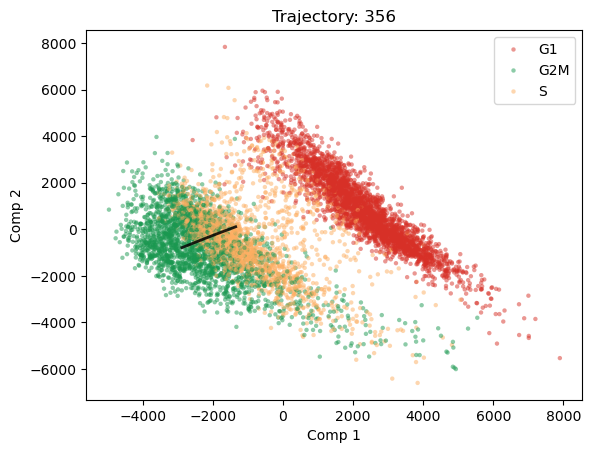

In [17]:
sampled_cell = np.random.randint(0, cells)
print(f"{sampled_cell=}")

coords = adata.obsm["X_pca"]  
x, y = coords[:, 0], coords[:, 1]

df = pd.DataFrame(data[:, sampled_cell, :2], columns=['comp1', 'comp2'])
df = df.reset_index(names='time')

sns.scatterplot(
    x=x, y=y, s=10, ec='none',
    hue=adata.obs['cluster_phase'], 
    palette=adata.uns['cluster_phase_colors'],
    alpha=0.5,
)

sns.lineplot(
    data=df, 
    x='comp1', 
    y='comp2', 
    c='k', lw=2,
    alpha=0.85,
)

plt.title(f'Trajectory: {sampled_cell}')
plt.xlabel("Comp 1")
plt.ylabel("Comp 2")


In [ ]:
break

# PHATE

In [ ]:
layer = 'scvi'

phate_operator = phate.PHATE(n_jobs=-2, random_state=42)
X_phate = phate_operator.fit_transform(adata.layers[layer])
adata.obsm['X_phate'] = X_phate.copy()
print(f"{X_phate.shape=}")

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sns.scatterplot(
    x=X_phate[:, 0],
    y=X_phate[:, 1],
    s=10, ec='none',
    hue=adata.obs['cluster_phase'], 
    palette=adata.uns['cluster_phase_colors'],
)

plt.title('PHATE')
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()

# Scale TrajectoryNet Outputs

In [ ]:
scaler = sklearn.preprocessing.StandardScaler()
scaler.fit(phate_operator.graph.data_nu)
print(f"{phate_operator.graph.data_nu.shape=}")


scaled_data = data * scaler.scale_[:components] + scaler.mean_[:components]
print(f"{scaled_data.shape=}")

In [ ]:
break

In [ ]:
sampled_cell = np.random.randint(0, cells)
print(f"{sampled_cell=}")

coords = adata.obsm["X_phate"]  
x, y = coords[:, 0], coords[:, 1]

df = pd.DataFrame(scaled_data[:, sampled_cell, :2], columns=['comp1', 'comp2'])
df = df.reset_index(names='time')
df.head()


sns.scatterplot(
    x=x, y=y, s=10, ec='none',
    hue=adata.obs['cluster_phase'], 
    palette=adata.uns['cluster_phase_colors'],
    alpha=0.5,
)

# sns.lineplot(
#     data=df, 
#     x='comp1', 
#     y='comp2', 
#     c='k', lw=2,
#     alpha=0.85
# )

# plt.title(f'Trajectory: {sampled_cell}')
# plt.xlabel("Comp 1")
# plt.ylabel("Comp 2")
# plt.xticks([])
# plt.yticks([])

In [ ]:
break

In [ ]:
sampled_cell = np.random.randint(0, cells)
print(f"{sampled_cell=}")

coords = adata.obsm["X_pca"]  
x, y = coords[:, 0], coords[:, 1]

df = pd.DataFrame(data[:, sampled_cell, :2], columns=['comp1', 'comp2'])
df = df.reset_index(names='time')

sns.scatterplot(
    x=x, y=y, s=10, ec='none',
    hue=adata.obs['cluster_phase'], 
    palette=adata.uns['cluster_phase_colors'],
    alpha=0.5,
)

sns.lineplot(
    data=df, 
    x='comp1', 
    y='comp2', 
    c='k', lw=2,
    alpha=0.85
)

plt.title(f'Trajectory: {sampled_cell}')
plt.xlabel("Comp 1")
plt.ylabel("Comp 2")
plt.xticks([])
plt.yticks([])

In [ ]:
break

# Visualize Trajectories

In [ ]:
sampled_cell = np.random.randint(0, cells)
print(f"{sampled_cell=}")

coords = adata.obsm["X_pca"]  
x, y = coords[:, 0], coords[:, 1]

df = pd.DataFrame(data[:, sampled_cell, :2], columns=['comp1', 'comp2'])
df = df.reset_index(names='time')

sns.scatterplot(
    x=x, y=y, s=10, ec='none',
    hue=adata.obs['cluster_phase'], 
    palette=adata.uns['cluster_phase_colors'],
    alpha=0.5,
)

sns.lineplot(
    data=df, 
    x='comp1', 
    y='comp2', 
    c='k', lw=2,
    alpha=0.85
)

plt.title(f'Trajectory: {sampled_cell}')
plt.xlabel("Comp 1")
plt.ylabel("Comp 2")
plt.xticks([])
plt.yticks([])

In [ ]:
break

In [ ]:
# Reshape to 2D: (timepoints * cells, comps)
reshaped = data.reshape(timepoints * cells, comps)

# Build DataFrame
df = pd.DataFrame(
    reshaped,
    columns=[f"PC_{i+1}" for i in range(comps)]
)

# Add metadata columns
df["timepoint"] = np.repeat(np.arange(timepoints), cells)
df["cell_id"] = np.tile(np.arange(cells), timepoints)

# Reorder columns: timepoint, cell_id, PCs
df = df[["timepoint", "cell_id"] + [f"PC_{i+1}" for i in range(comps)]]
df = df.sort_values(by=['cell_id', 'timepoint'])

print(df.head())

In [ ]:
sample_size = 10
x_column = "PC_1"
y_column = "PC_2"

# Pick random cells
sampled_cells = (
    df["cell_id"]
    .drop_duplicates()
    .sample(n=sample_size, random_state=0)  # fix seed for reproducibility
)

plt.figure(figsize=(6, 6), dpi=150)

for cell in sampled_cells:
    group = df[df["cell_id"] == cell].sort_values("timepoint")

    sns.lineplot(
        data=group,
        x=x_column,
        y=y_column,
        marker=".",
        lw=1,
        alpha=0.4,
        label=f"cell {cell}"
    )

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

# Make a UMAP 

In [ ]:
%%time
# 1) Get data to GPU (assumes adata.X already normalized/scaled)
Xg = cp.asarray(adata.obsm['X_pca'][:, :comps])
print(f"{Xg.shape=}")

# 2) Learn UMAP projection on GPU
umap = UMAP(
    n_neighbors=235,
    min_dist=1.0,
    n_components=2,
    metric="euclidean",      # e.g., "cosine"
    random_state=1729,
    output_type="cupy",
)
X_umap = umap.fit_transform(Xg)    # (cells × 2) on GPU
print(f"{X_umap.shape=}")

# 4) Store back to AnnData (host copy)
adata.obsm["X_umap"] = cp.asnumpy(X_umap)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3, 3

palette = {
    "G1": "#D73027",        
    "S": "#FDAE61",       
    "G2M": "#1A9850",    
}
    
sc.pl.umap(
    adata,
    color='cluster_phase',
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    palette=palette,
    title='Phase',
    frameon=False,
    wspace=0.25,
)

# Trajectories to UMAP

In [ ]:
%%time
# Suppose data.shape = (timepoints, cells, components)
timepoints, cells, comps = data.shape

# Apply UMAP transform per timepoint
umap_coords = np.zeros((timepoints, cells, 2))  # for 2D UMAP

for t in range(timepoints):
    coord_t = umap.transform(data[t])
    umap_coords[t] = cp.asnumpy(coord_t)

print(f"{umap_coords.shape=}")

# Static Plot

In [ ]:
# umap_coords.shape == (timepoints, cells, 2)
timepoints, cells, _ = umap_coords.shape

# --- Build tidy DataFrame ---
df = pd.DataFrame({
    "UMAP1": umap_coords[:, :, 0].ravel(),
    "UMAP2": umap_coords[:, :, 1].ravel(),
    "Time":  np.repeat(np.arange(timepoints), cells),
    "Cell":  np.tile(np.arange(cells), timepoints),
})

# Ensure rows are ordered within each cell by time (so lines connect correctly)
df = df.sort_values(["Cell", "Time"], kind="mergesort")

# (Optional) subsample cells to avoid clutter
max_cells_to_plot = 300  # adjust as needed
if cells > max_cells_to_plot:
    keep = np.random.choice(cells, size=max_cells_to_plot, replace=False)
    df_plot = df[df["Cell"].isin(keep)]
else:
    df_plot = df

# --- Plot: lines per cell + points colored by time ---
plt.figure(figsize=(6, 6), dpi=200)

# Draw one line per cell; sort=False uses the existing order (by Time within Cell)
sns.lineplot(
    data=df_plot,
    x="UMAP1", y="UMAP2",
    units="Cell", estimator=None, sort=False,
    lw=0.6, alpha=0.25, color="0.3"   # light gray lines
)

# Overlay points colored by time
sns.scatterplot(
    data=df_plot,
    x="UMAP1", y="UMAP2",
    hue="Time",
    palette="viridis", s=12, alpha=0.7, edgecolor=None
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("Trajectories in UMAP space (lines connect same cell over time)")
plt.legend(title="Time", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


# Animation

In [ ]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3, 3

# --- Static background ---
palette = {
    "G1": "#D73027",        
    "S": "#FDAE61",       
    "G2M": "#1A9850",    
    "unknown": "#B0B0B0", 
}
    
sc.pl.umap(
    adata,
    color='cluster_phase',
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    palette=palette,
    title='Phase',
    frameon=False,
    wspace=0.25,
    show=False,
)

fig = plt.gcf()
ax = plt.gca()

# --- Overlay for animation ---
timepoints, cells, _ = umap_coords.shape
scat = ax.scatter([], [], s=8, c="black", alpha=0.8)

def update(frame):
    xy = umap_coords[frame]      # shape (cells, 2)
    scat.set_offsets(xy)
    ax.set_title(f"UMAP overlay, time={frame}")
    return scat,

ani = FuncAnimation(fig, update, frames=timepoints, interval=100, blit=True)

# --- Show inline in Jupyter ---
HTML(ani.to_jshtml())

In [ ]:
break

In [ ]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3, 3

# --- Static background ---
palette = {
    "G1": "#D73027",        
    "S": "#FDAE61",       
    "G2M": "#1A9850",    
    "unknown": "#B0B0B0", 
}
    
sc.pl.umap(
    adata,
    color='cluster_phase',
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    palette=palette,
    title='Phase',
    frameon=False,
    wspace=0.25,
)

# Load inferred Trajectories

In [ ]:
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/cell_cycle/TrajectoryNet/backward_trajectories.npy"

data = np.load(fpath)
# shape is [timepoints, cells, components]
print(f"{data.shape=}")

In [ ]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3, 3

# --- Static background ---
palette = {
    "G1": "#D73027",        
    "S": "#FDAE61",       
    "G2M": "#1A9850",    
    "unknown": "#B0B0B0", 
}
    
sc.pl.umap(
    adata,
    color='cluster_phase',
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    palette=palette,
    title='Phase',
    frameon=False,
    wspace=0.25,
    show=False,
)

fig = plt.gcf()
ax = plt.gca()

# --- Overlay for animation ---
timepoints, cells, _ = data.shape
scat = ax.scatter([], [], s=8, c="black", alpha=0.8)

def update(frame):
    xy = data[frame]      # shape (cells, 2)
    scat.set_offsets(xy)
    ax.set_title(f"UMAP overlay, time={frame}")
    return scat,

ani = FuncAnimation(fig, update, frames=timepoints, interval=100, blit=True)

# --- Show inline in Jupyter ---
HTML(ani.to_jshtml())